In [122]:
import pandas as pd

train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

In [123]:
train.describe(include='all')

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
count,577347.00000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347,577347,577347
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,2,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M,Red_Sequence,GALAXY
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,303323,319565,377480
mean,288673.00000,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135,NaN,NaN,NaN
std,166665.86727,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070,NaN,NaN,NaN
min,0.00000,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970,NaN,NaN,NaN
25%,144336.50000,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052,NaN,NaN,NaN
50%,288673.00000,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525,NaN,NaN,NaN
75%,433009.50000,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390,NaN,NaN,NaN


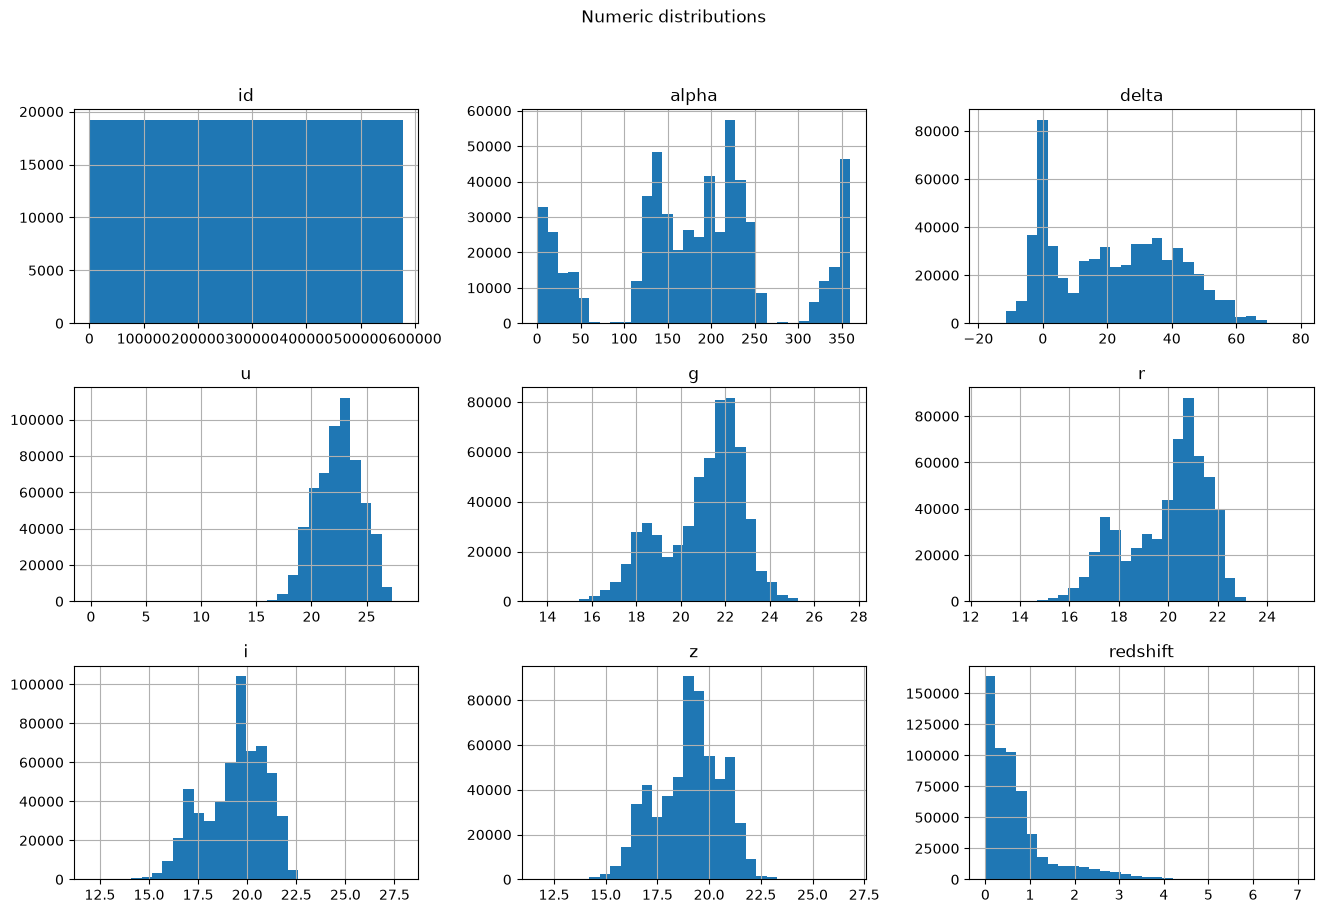

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = train.select_dtypes(include=['int64', 'float64']).columns

train[num_cols].hist(figsize=(16, 10), bins=30)
plt.suptitle("Numeric distributions")
plt.show()

In [125]:
#cat_cols = df.select_dtypes(include=['object', 'category']).columns

#for col in cat_cols:
#    print(f"\n{col}")
#    print(df[col].unique())

In [126]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    train.drop("class", axis=1), train["class"],
    test_size=0.2,
    random_state=42
)

In [127]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report
from xgboost import XGBClassifier
from sklearn.preprocessing import RobustScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
import numpy as np
import joblib
import gc

# признаки
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns

C:\Users\adik\AppData\Local\Temp\ipykernel_12240\170533337.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=["object", "category"]).columns


In [128]:
def log_transform(x):
    return np.log1p(x)

preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("log", FunctionTransformer(log_transform)),
        ("scaler", RobustScaler())
    ]), num_cols),

    ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=0.01), cat_cols)
])

clf = XGBClassifier(
    tree_method="hist",
    device="cuda",
    objective="multi:softprob",
    num_class=3,
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.05,
    random_state=42
)

pipeline = Pipeline([
            ("preprocess", preprocess),
            ("clf", clf)
])

In [129]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

pipeline.fit(X_train, y_train_enc)

c:\Users\adik\OneDrive\Desktop\Python\stars\.venv\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['id','alpha','delta',...,'redshift','spectral_type','galaxy_population']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all 

In [130]:
import os
import joblib
import numpy as np
from datetime import datetime
from sklearn.metrics import (
    classification_report,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    log_loss,
    confusion_matrix
)

def full_metrics(model, X_test, y_test, name="model", save_dir="models"):
    os.makedirs(save_dir, exist_ok=True)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    # ================= METRICS =================
    acc = accuracy_score(y_test, y_pred)
    f1_w = f1_score(y_test, y_pred, average="weighted")
    f1_m = f1_score(y_test, y_pred, average="macro")
    prec = precision_score(y_test, y_pred, average="weighted")
    rec = recall_score(y_test, y_pred, average="weighted")
    roc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
    ll = log_loss(y_test, y_proba)
    report = classification_report(y_test, y_pred, digits=6)
    cm = confusion_matrix(y_test, y_pred)

    # ================= PRINT =================
    print("\n================ METRICS ================\n")
    print("Accuracy:", acc)
    print("F1 weighted:", f1_w)
    print("F1 macro:", f1_m)
    print("Precision weighted:", prec)
    print("Recall weighted:", rec)
    print("ROC-AUC macro OVR:", roc)
    print("Log Loss:", ll)

    print("\nClassification report:\n")
    print(report)

    print("\nConfusion matrix:\n")
    print(cm)

    # ================= SAVE MODEL =================
    model_path = os.path.join(save_dir, f"{name}.pkl")
    joblib.dump(model, model_path)

    # ================= SAVE TXT REPORT =================
    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    txt_path = os.path.join(save_dir, f"{name}_{timestamp}.txt")

    with open(txt_path, "w", encoding="utf-8") as f:
        f.write("===== METRICS =====\n")
        f.write(f"Accuracy: {acc}\n")
        f.write(f"F1 weighted: {f1_w}\n")
        f.write(f"F1 macro: {f1_m}\n")
        f.write(f"Precision weighted: {prec}\n")
        f.write(f"Recall weighted: {rec}\n")
        f.write(f"ROC-AUC: {roc}\n")
        f.write(f"Log Loss: {ll}\n\n")

        f.write("===== CLASSIFICATION REPORT =====\n")
        f.write(report + "\n")

        f.write("===== CONFUSION MATRIX =====\n")
        f.write(np.array2string(cm))

    print(f"\nSaved model → {model_path}")
    print(f"Saved report → {txt_path}")

In [ ]:
full_metrics(pipeline, X_test, y_test_enc, name="XGB_v1")

c:\Users\adik\OneDrive\Desktop\Python\stars\.venv\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
c:\Users\adik\OneDrive\Desktop\Python\stars\.venv\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)



================ METRICS ================

Accuracy: 0.9672642244738893
F1 weighted: 0.9672680705226626
F1 macro: 0.9555584609674681
Precision weighted: 0.9672723331865448
Recall weighted: 0.9672642244738893
ROC-AUC macro OVR: 0.9962690274163729
Log Loss: 0.09107384830713272

Classification report:

              precision    recall  f1-score   support

           0   0.977333  0.977475  0.977404     75694
           1   0.965225  0.963688  0.964456     23243
           2   0.924090  0.925543  0.924816     16533

    accuracy                       0.967264    115470
   macro avg   0.955549  0.955569  0.955558    115470
weighted avg   0.967272  0.967264  0.967268    115470


Confusion matrix:

[[73989   679  1026]
 [  613 22399   231]
 [ 1103   128 15302]]

Saved model → models\XGB_v1.pkl
Saved report → models\XGB_v1_2026-06-18_14-31-33.txt


In [132]:
test_preds_enc = pipeline.predict(test)
test_preds = le.inverse_transform(test_preds_enc)

submission = pd.DataFrame({
    "id": test["id"],
    "class": test_preds
})

submission.to_csv("submission.csv", index=False)

c:\Users\adik\OneDrive\Desktop\Python\stars\.venv\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
